In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns

X_train_tree = pd.read_csv('data/X_train_tree.csv')
X_test_tree = pd.read_csv('data/X_test_tree.csv')
X_train_linear = pd.read_csv('data/X_train_linear.csv')
X_test_linear = pd.read_csv('data/X_test_linear.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze() # Squeeze I used for converting Dataframe to Series
y_test = pd.read_csv('data/y_test.csv').squeeze()

print('X_train shape:', X_train_tree.shape)
print('X_test shape:', X_test_tree.shape)

X_train shape: (27903, 37)
X_test shape: (6976, 37)


In [2]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_linear, y_train)

lr_pred = lr.predict(X_test_linear)

lr_mape = mean_absolute_percentage_error(y_test, lr_pred)
print(f'Linear Regression MAPE: {lr_mape:.2%}')

Linear Regression MAPE: 7.81%


In [12]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, 
                            random_state=42,
                            n_jobs=-1)
rf.fit(X_train_tree, y_train)

rf_pred = rf.predict(X_test_tree)

rf_mape = mean_absolute_percentage_error(y_test, rf_pred)
print(f'Random Forest MAPE: {rf_mape:.6%}')

Random Forest MAPE: 7.179023%


In [13]:
# XGBoost
xgb = XGBRegressor(n_estimators=100,
                    random_state=42,
                    n_jobs=-1,
                    verbosity=0)
xgb.fit(X_train_tree, y_train)

xgb_pred = xgb.predict(X_test_tree)

xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)
print(f'XGBoost MAPE: {xgb_mape:.2%}')

XGBoost MAPE: 8.15%


### XGBoost should perform better than Random forest. But it doesn't. Now I will try to tune the parameters of XGBoost

In [14]:
xgb_tuned = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    #early_stopping_rounds=50
)

xgb_tuned.fit(X_train_tree, y_train,
              eval_set=[(X_test_tree, y_test)],
              verbose=False)

xgb_tuned_pred = xgb_tuned.predict(X_test_tree)
xgb_tuned_mape = mean_absolute_percentage_error(y_test, xgb_tuned_pred)
print(f'XGBoost Tuned MAPE: {xgb_tuned_mape:.6%}')

XGBoost Tuned MAPE: 7.181545%


### Findings:
- XGBoost tuned is giving MAPE of 7.73% for n_estimators = 500, learning_rate = 0.05.
- With the increase in n_estimators to 1000 and learning_rate = 0.01, XGBoost overfits the data and give MAPE = 7.28%. Using early_stopping = 50, MAPE still reduces to 7.19% only.
- After multiple iteration, XGBoost reached MAPE of 7.18% having n_estimators = 500 and learning_rate = 0.01.

#### Comparison of different ML Models

Linear Regression MAPE: 0.078061
Random Forest MAPE: 0.071790
XGBoost Default MAPE: 0.081538
XGBoost Tuned MAPE: 0.071815


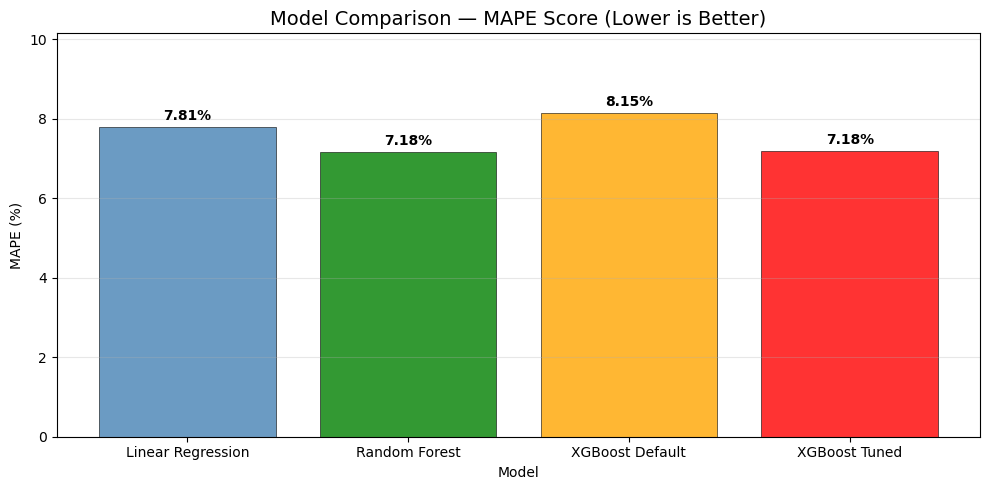

In [17]:
# Model Comparison Chart

# Check these are all defined
print(f'Linear Regression MAPE: {lr_mape:.6f}')
print(f'Random Forest MAPE: {rf_mape:.6f}')
print(f'XGBoost Default MAPE: {xgb_mape:.6f}')
print(f'XGBoost Tuned MAPE: {xgb_tuned_mape:.6f}')

models = ['Linear Regression', 'Random Forest', 
          'XGBoost Default', 'XGBoost Tuned']

mapes = [lr_mape, rf_mape, xgb_mape, xgb_tuned_mape]

plt.figure(figsize=(10, 5))
bars = plt.bar(models, 
               [m * 100 for m in mapes],
               color=['steelblue', 'green', 'orange', 'red'],
               alpha=0.8,
               edgecolor='black',
               linewidth=0.5)

# Add value labels on top of bars
for bar, mape in zip(bars, mapes):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{mape*100:.2f}%',
             ha='center',
             va='bottom',
             fontweight='bold')

plt.title('Model Comparison — MAPE Score (Lower is Better)',
          fontsize=14)
plt.xlabel('Model')
plt.ylabel('MAPE (%)')
plt.ylim(0, max([m * 100 for m in mapes]) + 2)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## Observation:
- Random Forest and XGBoost Tuned outperformed the linear regression model.
- Random Forest marginally outperformed tuned XGBoost (7.179% vs 7.182% MAPE) — a negligible difference suggesting both ensemble methods extract similar predictive information from the feature set. The near-identical performance indicates the dataset complexity is well suited to tree based ensemble methods.
- Notably XGBoost default parameters (8.15% MAPE) performed worse than Linear Regression (7.81%) — demonstrating that hyperparameter tuning is critical for XGBoost performance. After tuning, XGBoost improved by 0.97% percentage points — confirming the importance of learning rate and tree depth optimization.

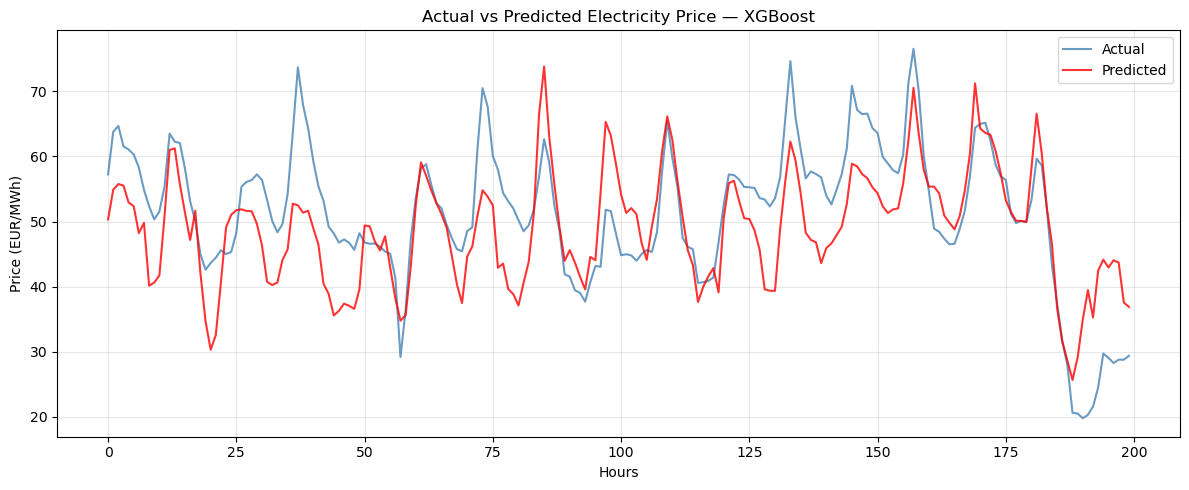

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], 
         label='Actual', 
         alpha=0.8,
         color='steelblue')
plt.plot(rf_pred[:200], 
         label='Predicted',
         alpha=0.8,
         color='red')
plt.title('Actual vs Predicted Electricity Price — XGBoost')
plt.xlabel('Hours')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

### Conclusion:
- The price trend predicted by Random Forest is very much precise to the actual price trend – capturing almost all high price spikes and low price periods the peaks with high accuracy. The model achieves 7.179% MAPE indicating predictions deviate by approximately 7.18% from actual prices on average — equivalent to approximately 4.16 EUR/MWh error on a mean price of 57.88 EUR/MWh.

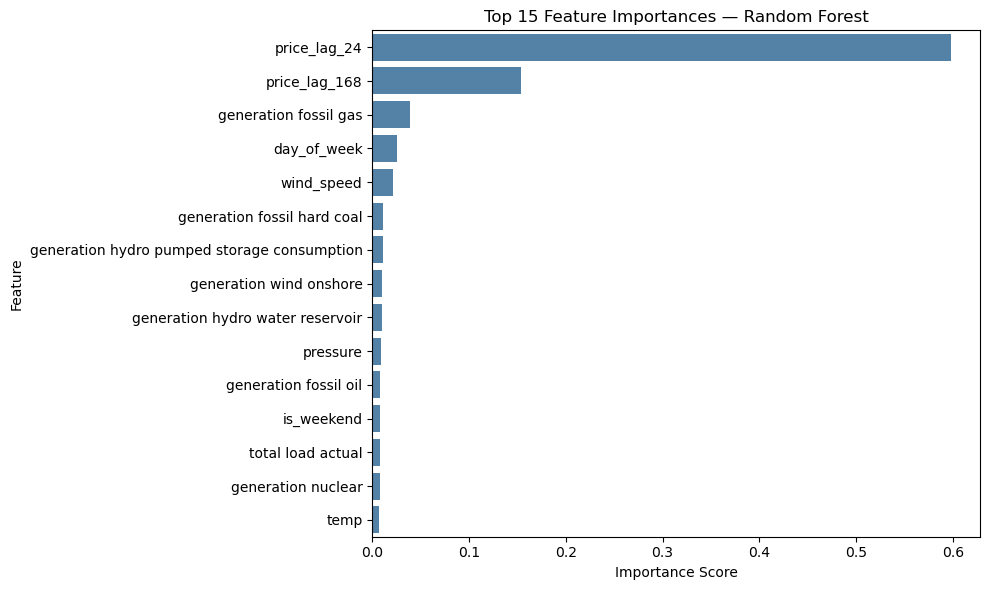

In [19]:
importance = pd.DataFrame({
    'feature': X_train_tree.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, 
            x='importance', 
            y='feature',
            color='steelblue')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()